In [90]:
from matplotlib import pyplot as plt
import numpy as np

# Grid representation:
A full 64x64 grid will contain 64x64 cells

Each cell can be a wall cell (0) or a open cell (1)

The outer border of cells is always going to be walls

This should come out as any easy visualization and hopefully be easy to learn

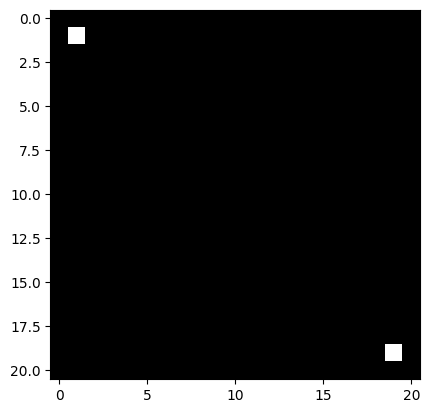

In [91]:
# Note, only works with odd numbers
GRID_SIZE = 21
grid = np.zeros((GRID_SIZE, GRID_SIZE))

# Arbitrary start/stop
START = (1, 1)
STOP = (GRID_SIZE - 2, GRID_SIZE - 2)
grid[START] = 1
grid[STOP] = 1

plt.imshow(grid, cmap='gray')

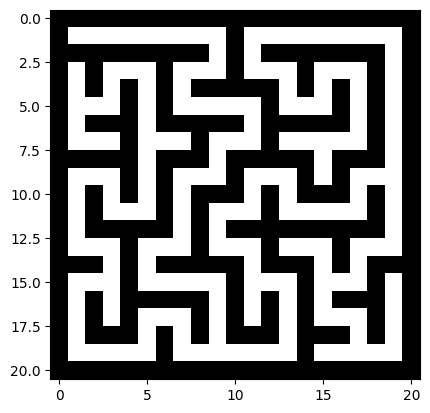

In [92]:
# Recursive backtracker
def neighbors(pos):
    dirs = np.array([[-2, 0], [0, -2], [0, 2], [2, 0]])
    ns = np.array(pos) + dirs

    valid_mask = (ns[:, 0] > 0) & (ns[:, 0] < GRID_SIZE - 1) & (ns[:, 1] > 0) & (ns[:, 1] < GRID_SIZE - 1)
    return list(map(tuple, ns[valid_mask]))

def generate_maze(grid, start):
    visited = set()
    stack = []
    visited.add(start)
    stack.append(start)

    while stack:
        curr = stack.pop(-1)
        ns = neighbors(curr)
        unvisited = [n for n in ns if n not in visited]
        if unvisited:
            stack.append(curr)
            chosen = unvisited[np.random.randint(0, len(unvisited))]
            grid[tuple(np.mean([curr, chosen], axis=0, dtype=int))] = 1
            grid[chosen] = 1
            visited.add(chosen)
            stack.append(chosen)

    return grid

# Reset the grid before generating to clear any previous corrupted runs
grid = np.zeros((GRID_SIZE, GRID_SIZE))
grid[START] = 1
grid[STOP] = 1

grid = generate_maze(grid, START)
plt.imshow(grid, cmap='gray')


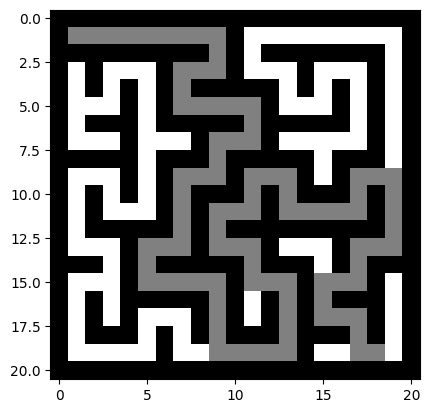

In [93]:
from collections import defaultdict
from queue import PriorityQueue

def neighbors(grid, pos):
    dirs = np.array([[-1, 0], [0, -1], [0, 1], [1, 0]])
    ns = np.array(pos) + dirs

    valid_mask = (ns[:, 0] > 0) & (ns[:, 0] < GRID_SIZE - 1) & (ns[:, 1] > 0) & (ns[:, 1] < GRID_SIZE - 1)
    rows, cols = zip(*ns)
    return list(map(tuple, ns[valid_mask & list(map(bool, grid[rows, cols]))]))

def find_path(grid, start, stop):
    open_set = PriorityQueue()
    came_from = {}
    g_score = defaultdict(lambda: 99999999)
    g_score[start] = 0

    h = lambda x: sum(stop) - sum(x)

    f_score = defaultdict(lambda: 99999999)
    f_score[start] = h(start)

    open_set.put((f_score[start], start))

    while not open_set.empty():
        current = open_set.get()
        currpos = current[1]
        if currpos == stop:
            final_path = []
            while currpos in came_from.keys():
                currpos = came_from[currpos]
                final_path.append(currpos)
            return final_path

        for n in neighbors(grid, currpos):
            tentative_g_score = g_score[currpos] + 1
            if tentative_g_score < g_score[n]:
                came_from[n] = currpos
                g_score[n] = tentative_g_score
                f_score[n] = g_score[n] + h(n)
                open_set.put((f_score[n], n))

    return False

path = find_path(grid, START, STOP)
rows, cols = zip(*path)
grid[rows, cols] = 0.5
plt.imshow(grid, cmap='gray')